In [1]:
import pysam
import pandas as pd
from collections import defaultdict
from pathlib import Path

# Downlaod Subsetted BAM files around TAF1

In [2]:
df_libraries = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/SlideTags_XDP_metadata/XDP Slidetags - CellBender Terra table - cb.csv")
df_libraries.head()

,entity:library_id,donor_number,donor_id,condition,sex,age_at_onset,age_at_death,bcl,RNAindex,SBindex,...,cellranger_count_h5,terra_slidetag,terra_cellbender,terra_dropsift,script_01_adata,script_02_mmc,script_03_QC,script_04_merge,script_05_zone (4 / 6),script_06_ct_for_deg
0,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1,sample_01,SCF-18-003,diseased,male,32.0,41,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H1,SI-TT-H4,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
1,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H2,sample_01,SCF-18-003,diseased,male,32.0,41,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H2,SI-TT-H5,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
2,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H3,sample_01,SCF-18-003,diseased,male,32.0,41,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H3,SI-TT-H6,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
3,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B10,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B10,SI-TT-A11,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
4,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B11,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B11,SI-TT-A12,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN


In [ ]:
for _, row in df_libraries.iterrows():
    lib, bcl, sample = row["entity:library_id"], row["entity:bcl_id"], row["entity:sample_id"]

    %%bash
    set -e #makes bash abort the moment any command fails, instead of blindly continuing

    SAMPLE="sample_02"
    BCL="260313_SL-EXA_0758_B23GHNHLT4"
    LIBRARY="SI-TT-C1" # one bam per librrary
    SAVE_FOLDER="$HOME/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/$SAMPLE/$BCL/$LIBRARY/bam"

    mkdir -p "$SAVE_FOLDER"
    cd "$SAVE_FOLDER"

    BAM="gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/$BCL/$LIBRARY/outs/possorted_genome_bam.bam"

    export GCS_OAUTH_TOKEN=$(gcloud auth print-access-token)

    # genomi location form https://www.genecards.org/card/TAF1#igv-div --> chrX:71,366,131-71,532,374
    # run mutiple commnds in the container( &&)
    samtools view -b \
    "$BAM" \
    chrX:71300000-71600000 \
    -o taf1_subset.bam && \
    samtools index taf1_subset.bam && \
    samtools view taf1_subset.bam | head -1

In [ ]:
%%bash
set -e #makes bash abort the moment any command fails, instead of blindly continuing

SAMPLE="sample_02"
BCL="260313_SL-EXA_0758_B23GHNHLT4"
LIBRARY="SI-TT-C1" # one bam per librrary
SAVE_FOLDER="$HOME/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/$SAMPLE/$BCL/$LIBRARY/bam"

mkdir -p "$SAVE_FOLDER"
cd "$SAVE_FOLDER"

BAM="gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/$BCL/$LIBRARY/outs/possorted_genome_bam.bam"

export GCS_OAUTH_TOKEN=$(gcloud auth print-access-token)

# genomi location form https://www.genecards.org/card/TAF1#igv-div --> chrX:71,366,131-71,532,374
# run mutiple commnds in the container( &&)
samtools view -b \
  "$BAM" \
  chrX:71366000-71540000 \
  -o taf1_subset.bam && \
samtools index taf1_subset.bam && \
samtools view taf1_subset.bam | head -1


lh00125:758:23GHNHLT4:6:1131:25521:13121	16	chrX	70988871	255	41M500091N49M	*	0	0	GAGGCTGAGGCAGGAGAATGACTTGAACCCGGGAGGCAGAGGCTGCAGCGAGCCGAGATCGCACCACTGCACTCCAGCCTGAGCAACAGA	IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII	NH:i:1	HI:i:1	AS:i:81	nM:i:2	RG:Z:SI-TT-C1:0:1:23GHNHLT4:6	RE:A:I	xf:i:0	CR:Z:GGGCCTGGTGGCCAGC	CY:Z:IIIIIIIIIIIIIIII	UR:Z:ACTTTGGGCCGA	UY:Z:IIIIIIIIIIII	UB:Z:ACTTTGGGCCGA


# TAF1 intron-32 / cryptic exon quantification

### Verigy wher egene and exons are in ref geneome

In [7]:
%%bash

GTF=/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/genome_fasta/refdata-gex-GRCh38-2024-A/genes/genes.gtf.gz

# gene span
zcat "$GTF" | awk -F'\t' '$3=="gene"' | grep 'gene_name "TAF1"'

# exons of the MANE Select / canonical transcript
zcat "$GTF" | awk -F'\t' '$3=="exon"' | grep 'gene_name "TAF1"' | grep 'transcript_id "ENST00000423759' | tail -n 5


chrX	HAVANA	gene	71366222	71532374	.	+	.	gene_id "ENSG00000147133"; gene_version "17"; gene_type "protein_coding"; gene_name "TAF1"; level 1; hgnc_id "HGNC:11535"; tag "ncRNA_host"; havana_gene "OTTHUMG00000022723.7";
chrX	HAVANA	exon	71454741	71454857	.	+	.	gene_id "ENSG00000147133"; gene_version "17"; transcript_id "ENST00000423759"; transcript_version "6"; gene_type "protein_coding"; gene_name "TAF1"; transcript_type "protein_coding"; transcript_name "TAF1-204"; exon_number 34; exon_id "ENSE00003631125"; exon_version "1"; level 2; protein_id "ENSP00000406549.2"; transcript_support_level "5"; hgnc_id "HGNC:11535"; tag "CAGE_supported_TSS"; tag "upstream_ATG"; tag "basic"; tag "Ensembl_canonical"; tag "MANE_Select"; tag "appris_principal_4"; tag "CCDS"; ccdsid "CCDS14412.2"; havana_gene "OTTHUMG00000022723.7"; havana_transcript "OTTHUMT00000058996.3";
chrX	HAVANA	exon	71458241	71458366	.	+	.	gene_id "ENSG00000147133"; gene_version "17"; transcript_id "ENST00000423759"; transcript_vers

In [3]:
REGIONS = {
    "taf1_gene":       ("chrX", 71366131, 71532374), # https://www.genecards.org/card/TAF1#Genomics
    "exon32":          ("chrX", 71424154, 71424238), # https://www.genecards.org/card/TAF1#Genomics
    "exon33":          ("chrX", 71454170, 71454237), # https://www.genecards.org/card/TAF1#Genomics
    "intron32":        ("chrX", 71424239, 71454169), # subtraction
    "exon34":          ("chrX", 71454741, 71454857), # https://www.genecards.org/card/TAF1#Genomics

    # from ex32 to right before SVA
    "retain_32i":      ("chrX", 71424239, 71440488), # ZNF91 paper - "Analysis of RNA Sequencing Data": https://pmc.ncbi.nlm.nih.gov/articles/PMC11331120/#s10
    "pre_SVA":         ("chrX", 71366131, 71440488), # based on rest: start taf1 - start SVA
    "post_SVA":        ("chrX", 71440488, 71532374), # based on rest: start SVA - end taf1
    # criptic exons inside "reatain_32i": after ex23 and befoee SVA
    "cryptic_32i_window": ("chrX", 71438000, 71440488),  # approximate;
    #"cryptic_32i":     ("chrX", , ), 

    # total exons
    # total introns
    # SVA site --> not possibel in referecne genome
}

/tmp/ipykernel_3235365/2187036208.py:49: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color="#e8e8e8", edgecolor="black", label="intron32 (full)"),
/tmp/ipykernel_3235365/2187036208.py:50: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color="#ffcc80", edgecolor="black", label="retain_32i"),


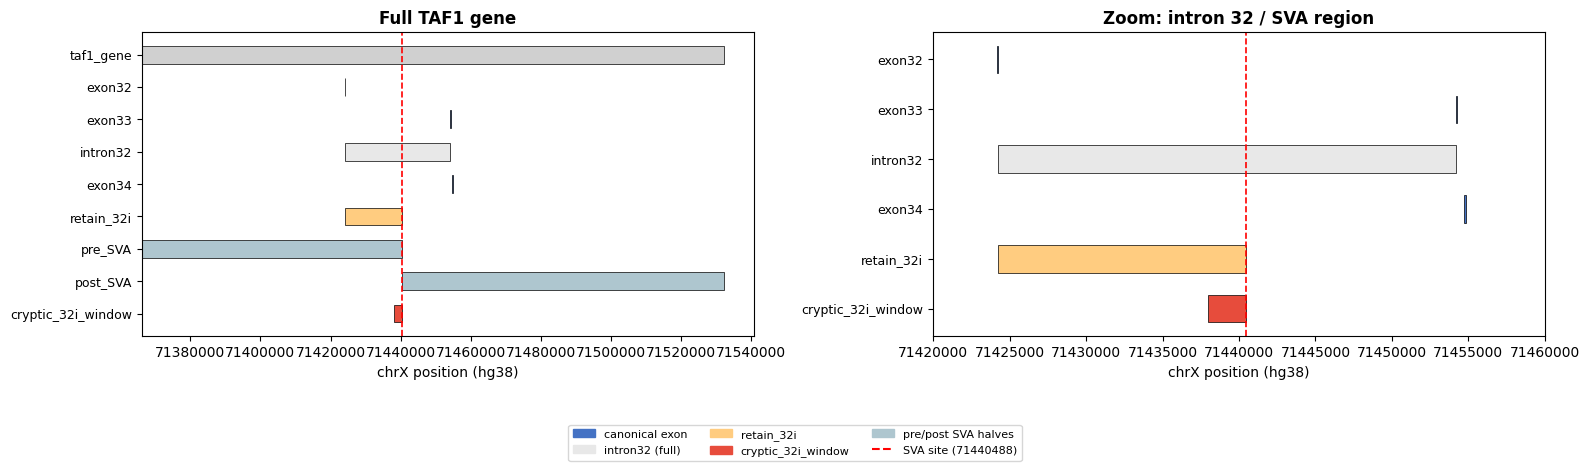

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLORS = {
    "taf1_gene":          "#d0d0d0",
    "pre_SVA":            "#aec6cf",
    "post_SVA":           "#aec6cf",
    "intron32":           "#e8e8e8",
    "retain_32i":         "#ffcc80",
    "exon32":             "#4472C4",
    "exon33":             "#4472C4",
    "exon34":             "#4472C4",
    "cryptic_32i_window": "#e74c3c",
}

SVA_POS = 71440488  # SVA insertion boundary

def draw_tracks(ax, regions, xlim=None):
    names = list(regions.keys())
    for i, name in enumerate(names):
        _, start, end = regions[name]
        y = len(names) - 1 - i
        ax.barh(y, end - start, left=start, height=0.55,
                color=COLORS.get(name, "#999999"),
                edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(list(reversed(names)), fontsize=9)
    ax.axvline(SVA_POS, color="red", lw=1.2, ls="--")
    if xlim:
        ax.set_xlim(xlim)
    ax.ticklabel_format(axis="x", style="plain")
    ax.set_xlabel("chrX position (hg38)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4),
                                gridspec_kw={"width_ratios": [1, 1]})

# full gene
draw_tracks(ax1, REGIONS)
ax1.set_title("Full TAF1 gene", fontweight="bold")

# zoom into intron 32
ZOOM = {k: v for k, v in REGIONS.items()
        if k not in ("taf1_gene", "pre_SVA", "post_SVA")}
draw_tracks(ax2, ZOOM, xlim=(71420000, 71460000))
ax2.set_title("Zoom: intron 32 / SVA region", fontweight="bold")

legend_items = [
    mpatches.Patch(color="#4472C4",                   label="canonical exon"),
    mpatches.Patch(color="#e8e8e8", edgecolor="black", label="intron32 (full)"),
    mpatches.Patch(color="#ffcc80", edgecolor="black", label="retain_32i"),
    mpatches.Patch(color="#e74c3c",                   label="cryptic_32i_window"),
    mpatches.Patch(color="#aec6cf",                   label="pre/post SVA halves"),
    plt.Line2D([0], [0], color="red", ls="--",        label="SVA site (71440488)"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.18), fontsize=8)

plt.tight_layout()
plt.show()


In [5]:
BAM = Path("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam")


### Load called-cell barcodes (needed before quantification + regtools)

Moved up from the old "Add info to adata" section at the bottom of this notebook: both `regtools` (Step A) and the per-cell CIGAR classifier (Step B) below need the called-cell barcode allowlist before they run.

In [6]:
import scanpy as sc

adata = sc.read_h5ad(
    "/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata.h5ad",
    backed="r",
)
adata_s = adata[
    (adata.obs["sample"] == "sample_02") &
    (adata.obs["library"] == "SI-TT-C1")
    ].to_memory().copy()
adata_s

AnnData object with n_obs × n_vars = 14217 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'original_barcode', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted'
    var: 'feature_types', 'genome', 'gene_symbol', 'n_cells'
    obsm: 'spatial'
    layers: 'counts'

In [ ]:
import pysam
bam = pysam.AlignmentFile("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam", "rb")
r = next(bam)
print("QNAME", r.query_name)
print("RNAME", r.reference_name)
print("POS",   r.reference_start + 1)   # pysam is 0-based; SAM POS is 1-based leftmost position (1-based)
print("FLAG",  r.flag)
print("CIGAR", r.cigarstring)
print("CB", r.get_tag("CB"), "UB", r.get_tag("UB"), "GN", r.get_tag("GN"))

QNAME lh00125:758:23GHNHLT4:6:1131:25521:13121
RNAME chrX
POS 70988871
FLAG 16
CIGAR 41M500091N49M


KeyError: "tag 'CB' not present"

In [29]:
%%bash
BAM="/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam"

# tally counted molecules by region (E/N/I)
samtools view -e '[xf]==25' "$BAM" 2>/dev/null \
  | grep -oP 'RE:A:\K[ENI]' \
  | sort | uniq -c

  32379 E
  25127 N


In [21]:
!samtools view -c -e '[xf]==25' /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam chrX:71366131-71532374

!samtools view -c -e '[xf]==25 && [RE]=="E"' /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam chrX:71366131-71532374

!samtools view -e '[xf]==25' /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam | grep -oP 'RE:A:\K[ENI]' | sort | uniq -c


26108
8686
  32379 E
  25127 N


In [7]:
obs_index = adata_s.obs.index  # composite index (bcl---library---barcode); kept only to restore adata_s.obs.index after the merge below
CALLED_CELLS = set(adata_s.obs["original_barcode"])  # raw 10x barcode, matches BAM CB tag format

# sanity check barcode format matches BAM
with pysam.AlignmentFile(str(BAM), "rb") as bam:
    for read in bam.fetch("chrX", 71300000, 71310000):
        if read.has_tag("CB"):
            bam_cb = read.get_tag("CB")
            print(f"BAM barcode example      : {bam_cb}")
            print(f"original_barcode example : {adata_s.obs['original_barcode'].iloc[0]}")
            print(f"Format match: {bam_cb in CALLED_CELLS}")
            break

BARCODES_FILE = BAM.parent / "called_cell_barcodes.txt"
BARCODES_FILE.write_text("\n".join(sorted(CALLED_CELLS)) + "\n")
print(f"{len(CALLED_CELLS)} called cells -> {BARCODES_FILE}")

BAM barcode example      : CTTGAATAGATCCGTA-1
original_barcode example : AAACCAAAGACGGAGC-1
Format match: True
14217 called cells -> /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/called_cell_barcodes.txt


### Step A — Discover & validate splice junctions with `regtools` (called cells only)

Uses [regtools](https://regtools.readthedocs.io/) `junctions extract` — a tested, CIGAR-aware splice-junction caller (same tool used in GTEx/LeafCutter-style splicing pipelines) — instead of hand-rolled `fetch()` window overlap, which can't distinguish a spliced-through read from a retained-intron read (both have an alignment span covering the intron window).

Notes from testing this against `taf1_subset.bam`:
- No `XS` tag in this BAM (CellRanger STAR doesn't emit it here) → can't use `-s XS`.
- `-s RF` correctly recovers `+`-strand junctions, consistent with TAF1 being Ensembl `strand=1` and with the `is_reverse`-based strand filter already used below for 10x 3' chemistry.
- `-b <barcodes>` filters *input* reads to the called-cell allowlist but does **not** give a per-cell breakdown — it's one aggregate junction list. Per-cell UMI counting is still done ourselves in Step B, using the junction coordinates regtools validates here.

In [8]:
REGTOOLS_IMAGE = "quay.io/biocontainers/regtools:1.0.0--h077b44d_5"
JUNCTIONS_BED = BAM.parent / "taf1_junctions.bed"
_, gene_start, gene_end = REGIONS["taf1_gene"]

cmd = f"""podman run --rm -v {BAM.parent}:/data {REGTOOLS_IMAGE} \
  regtools junctions extract \
  -s RF -a 8 -m 70 -M 500000 \
  -b /data/{BARCODES_FILE.name} \
  -r chrX:{gene_start}-{gene_end} \
  -o /data/{JUNCTIONS_BED.name} \
  /data/{BAM.name}"""
print(cmd)
!{cmd}

podman run --rm -v /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam:/data quay.io/biocontainers/regtools:1.0.0--h077b44d_5   regtools junctions extract   -s RF -a 8 -m 70 -M 500000   -b /data/called_cell_barcodes.txt   -r chrX:71366131-71532374   -o /data/taf1_junctions.bed   /data/taf1_subset.bam

Program:	regtools
Version:	1.0.0
Minimum junction anchor length: 8
Minimum intron length: 70
Maximum intron length: 500000
Alignment: /data/taf1_subset.bam
Output file: /data/taf1_junctions.bed
Barcode file: /data/called_cell_barcodes.txt



In [9]:
BED12_COLS = ["chrom", "start", "end", "name", "score", "strand",
              "thickStart", "thickEnd", "itemRgb", "blockCount", "blockSizes", "blockStarts"]
df_junctions = pd.read_csv(JUNCTIONS_BED, sep="\t", header=None, names=BED12_COLS)

def _intron_bounds(row):
    sizes = [int(x) for x in row["blockSizes"].strip(",").split(",")]
    return row["start"] + sizes[0], row["end"] - sizes[1]

df_junctions[["intron_start", "intron_end"]] = df_junctions.apply(_intron_bounds, axis=1, result_type="expand")
df_junctions = df_junctions.sort_values("score", ascending=False).reset_index(drop=True)
print(df_junctions.shape)
df_junctions.head(20)

(829, 14)


,chrom,start,end,name,score,strand,thickStart,thickEnd,itemRgb,blockCount,blockSizes,blockStarts,intron_start,intron_end
0,chrX,71367526,71368139,JUNC00000334,584,?,71367526,71368139,"255,0,0",2,"87,86","0,527",71367613,71368053
1,chrX,71366407,71367585,JUNC00000299,329,?,71366407,71367585,"255,0,0",2,"87,87","0,1091",71366494,71367498
2,chrX,71459621,71460711,JUNC00000330,288,?,71459621,71460711,"255,0,0",2,"87,86","0,1004",71459708,71460625
3,chrX,71368083,71375252,JUNC00000344,287,?,71368083,71375252,"255,0,0",2,"87,86","0,7083",71368170,71375166
4,chrX,71375199,71377035,JUNC00000365,170,+,71375199,71377035,"255,0,0",2,"87,86","0,1750",71375286,71376949
5,chrX,71407585,71408059,JUNC00000513,163,?,71407585,71408059,"255,0,0",2,"87,86","0,388",71407672,71407973
6,chrX,71397379,71398657,JUNC00000468,156,?,71397379,71398657,"255,0,0",2,"87,86","0,1192",71397466,71398571
7,chrX,71421291,71423203,JUNC00000506,156,?,71421291,71423203,"255,0,0",2,"85,87","0,1825",71421376,71423116
8,chrX,71375199,71377036,JUNC00000366,151,?,71375199,71377036,"255,0,0",2,"87,87","0,1750",71375286,71376949
9,chrX,71408064,71421390,JUNC00000515,148,?,71408064,71421390,"255,0,0",2,"87,82","0,13244",71408151,71421308


In [10]:
_, intron32_start, intron32_end = REGIONS["intron32"]
_, retain_start, retain_end = REGIONS["retain_32i"]

# canonical exon32->exon33 junction: '+' strand, closely matching the hand-annotated intron32 bounds
candidate = df_junctions[
    (df_junctions["strand"] == "+") &
    (df_junctions["intron_start"].between(intron32_start - 20, intron32_start + 20)) &
    (df_junctions["intron_end"].between(intron32_end - 20, intron32_end + 20))
].sort_values("score", ascending=False)

assert len(candidate) > 0, "No canonical exon32-exon33 junction found by regtools -- check strand/anchor settings"
CANONICAL_JUNCTION = (int(candidate.iloc[0]["intron_start"]), int(candidate.iloc[0]["intron_end"]))
print("Canonical exon32->exon33 junction (regtools-validated):", CANONICAL_JUNCTION,
      f"(hand-annotated REGIONS['intron32'] was {(intron32_start, intron32_end)})")

# any other well-supported junction with a donor/acceptor inside retain_32i / near the SVA boundary
# -> candidate cryptic/novel splice event, replacing the hand-guessed cryptic_32i_window
in_retain_window = lambda pos: retain_start <= pos <= retain_end
cryptic_candidates = df_junctions[
    (df_junctions["intron_start"].apply(in_retain_window) | df_junctions["intron_end"].apply(in_retain_window)) &
    ~((df_junctions["intron_start"] == CANONICAL_JUNCTION[0]) & (df_junctions["intron_end"] == CANONICAL_JUNCTION[1]))
].sort_values("score", ascending=False)

CRYPTIC_JUNCTIONS = list(zip(cryptic_candidates["intron_start"].astype(int), cryptic_candidates["intron_end"].astype(int)))
print(f"{len(CRYPTIC_JUNCTIONS)} candidate cryptic junction(s) with an end inside retain_32i:")
cryptic_candidates[["intron_start", "intron_end", "score", "strand"]]

Canonical exon32->exon33 junction (regtools-validated): (71424238, 71454169) (hand-annotated REGIONS['intron32'] was (71424239, 71454169))
85 candidate cryptic junction(s) with an end inside retain_32i:


,intron_start,intron_end,score,strand
92,71308814,71430998,5,+
97,71424181,71432225,5,?
115,71427607,71612282,3,+
159,71386164,71426715,2,?
170,71428936,71509753,2,?
...,...,...,...,...
762,71375698,71430255,1,?
771,71366609,71430297,1,?
780,71367765,71424719,1,+
810,71381331,71437900,1,?


### Step B — Per-cell, UMI-deduplicated classification (CIGAR/junction-aware)

Replaces `fetch()`-window overlap for intron-adjacent categories. Classifies each read by walking its CIGAR against the regtools-validated junction(s) from Step A, then counts unique UMIs per cell per category (same CB+UB/NH filtering as before, which was already correct).

In [11]:
def classify_boundary_reads_per_cell(bam_path, chrom, start, end,
                                      canonical_junction,
                                      cryptic_junctions,
                                      retention_anchor_pos,
                                      anchor_len=8,
                                      strand="+",
                                      unique_only=True):
    """
    Classify UMI-level reads overlapping the exon32/intron32 boundary by CIGAR, replacing
    fetch()-window overlap (which can't tell a spliced-through read from a retained-intron
    read -- both have an alignment span covering the window).

      spliced_canonical : read's CIGAR has an N-op exactly matching `canonical_junction`
      spliced_cryptic   : read's CIGAR has an N-op exactly matching one of `cryptic_junctions`
      retained          : read has >= anchor_len bp of *aligned* (M/=/X) sequence on both
                           sides of `retention_anchor_pos` with no N-op between them
                           (IRFinder-style boundary-spanning retention evidence)
      other             : overlaps the region but doesn't clearly fall into the above
                           (e.g. reads fully inside the intron, away from any boundary)

    Reads without both CB and UB tags are dropped (can't be assigned to a cell/UMI); counted
    in qc["dropped_no_barcode_or_umi"].
    """
    cat_umis = {c: defaultdict(set) for c in ("spliced_canonical", "spliced_cryptic", "retained", "other")}
    qc = defaultdict(int)
    consumes_ref_aligned = {0, 7, 8}   # M, =, X: read bases aligned to the reference
    consumes_ref_only = {2, 3}         # D, N: reference consumed, no read base

    with pysam.AlignmentFile(str(bam_path), "rb") as bam:
        for read in bam.fetch(chrom, start, end):
            qc["total_overlapping"] += 1
            if read.is_unmapped or read.is_secondary or read.is_supplementary:
                continue
            if strand == "+" and not read.is_reverse:
                continue
            if strand == "-" and read.is_reverse:
                continue
            if unique_only and read.has_tag("NH") and read.get_tag("NH") > 1:
                qc["dropped_multimapper"] += 1
                continue
            cb = read.get_tag("CB") if read.has_tag("CB") else None
            ub = read.get_tag("UB") if read.has_tag("UB") else None
            if not (cb and ub):
                qc["dropped_no_barcode_or_umi"] += 1
                continue

            ref_pos = read.reference_start
            n_ops = []
            aligned_blocks = []
            for op, length in read.cigartuples:
                if op == 3:  # N (splice)
                    n_ops.append((ref_pos, ref_pos + length))
                if op in consumes_ref_aligned:
                    aligned_blocks.append((ref_pos, ref_pos + length))
                if op in consumes_ref_aligned or op in consumes_ref_only:
                    ref_pos += length

            category = "other"
            if (canonical_junction is not None) and any(j == canonical_junction for j in n_ops):
                category = "spliced_canonical"
            elif any(j in cryptic_junctions for j in n_ops):
                category = "spliced_cryptic"
            elif retention_anchor_pos is not None:
                spans = any(
                    b_start <= retention_anchor_pos - anchor_len and b_end >= retention_anchor_pos + anchor_len
                    for b_start, b_end in aligned_blocks
                )
                if spans:
                    category = "retained"

            cat_umis[category][cb].add(ub)

    result = {c: {cb: len(u) for cb, u in d.items()} for c, d in cat_umis.items()}
    qc["dropped_no_barcode_or_umi_frac"] = (
        qc["dropped_no_barcode_or_umi"] / qc["total_overlapping"] if qc["total_overlapping"] else float("nan")
    )
    return result, dict(qc)

In [12]:
_, exon32_start, exon32_end = REGIONS["exon32"]
_, exon33_start, exon33_end = REGIONS["exon33"]

# fetch window spans exon32 -> exon33 (covers the whole canonical intron; a read overlapping
# any part of that span, spliced or retained, will be picked up and then classified by CIGAR)
class_counts, qc = classify_boundary_reads_per_cell(
    BAM, "chrX", exon32_start, exon33_end,
    canonical_junction=CANONICAL_JUNCTION,
    cryptic_junctions=CRYPTIC_JUNCTIONS,
    retention_anchor_pos=exon32_end,  # exon32/intron32 boundary -- matches the Aneichyk et al. 2018 TAF1-32i assay design
    anchor_len=8,
    strand="+",
)

print("QC:", qc)

df_class = pd.DataFrame(class_counts).fillna(0).astype(int)
df_class.index.name = "cell_barcode"
df_class["retention_ratio"] = df_class["retained"] / (df_class["retained"] + df_class["spliced_canonical"])
print(df_class.shape)
df_class.head()

QC: {'total_overlapping': 15147, 'dropped_no_barcode_or_umi': 1195, 'dropped_multimapper': 207, 'dropped_no_barcode_or_umi_frac': 0.07889351026605929}
(4298, 5)


,spliced_canonical,spliced_cryptic,retained,other,retention_ratio
cell_barcode,,,,,
GTCATACCAACGATAG-1,1,0,0,1,0.0
GCATAGACACACAATC-1,1,0,0,0,0.0
AATTCGTAGCAAAGTA-1,1,0,0,1,0.0
CAATTCCTCCAGTCCC-1,1,0,0,1,0.0
AAGTACGCAATTAAGA-1,1,0,0,0,0.0


In [13]:
def count_umis_per_cell(bam_path, chrom, start, end,
                        strand="+",       # "+" or "-" or None to skip
                        unique_only=True):
    """
    Raw fetch()-window UMI counting. Only valid for windows that can't be crossed by a
    splice N-op (exons, or the whole-gene span) -- for anything intron-adjacent (intron32,
    retain_32i, cryptic_32i_window, pre_SVA/post_SVA) a spliced-through read's *alignment
    span* still overlaps the window even though none of its sequenced bases are intronic,
    which silently inflates those counts. See classify_boundary_reads_per_cell() above for
    the CIGAR-aware replacement used for those categories.

    For 10x 3' chemistry:
      + strand gene -> reads are is_reverse=True
      - strand gene -> reads are is_reverse=False
    """
    cell_umis = defaultdict(set)
    with pysam.AlignmentFile(str(bam_path), "rb") as bam:
        for read in bam.fetch(chrom, start, end):
            if read.is_unmapped or read.is_secondary or read.is_supplementary:
                continue
            # strand filter (10x 3' convention: cDNA read is antisense)
            if strand == "+" and not read.is_reverse:
                continue
            if strand == "-" and read.is_reverse:
                continue
            # unique-mapper filter
            if unique_only and read.has_tag("NH") and read.get_tag("NH") > 1:
                continue
            cb = read.get_tag("CB") if read.has_tag("CB") else None
            ub = read.get_tag("UB") if read.has_tag("UB") else None
            if cb and ub:
                cell_umis[cb].add(ub)
    return {cb: len(umis) for cb, umis in cell_umis.items()}


In [14]:
WINDOW_SAFE = ["taf1_gene", "exon32", "exon33", "exon34"]
# NOTE: pre_SVA/post_SVA/intron32/retain_32i/cryptic_32i_window are intentionally NOT
# computed here -- a read spliced across the intron has its *alignment span* crossing these
# windows too (the same fetch()-vs-CIGAR issue as intron32), so raw window counting isn't
# valid for them. See classify_boundary_reads_per_cell() / df_class above instead.

counts = {}
for region_name in WINDOW_SAFE:
    chrom, start, end = REGIONS[region_name]
    print(f"Counting {region_name} ({chrom}:{start}-{end}) ...")
    counts[region_name] = count_umis_per_cell(BAM, chrom, start, end, strand="+")

Counting taf1_gene (chrX:71366131-71532374) ...
Counting exon32 (chrX:71424154-71424238) ...
Counting exon33 (chrX:71454170-71454237) ...
Counting exon34 (chrX:71454741-71454857) ...


In [15]:
df = pd.DataFrame(counts).fillna(0).astype(int)
df = df.join(df_class.drop(columns="retention_ratio"), how="outer").fillna(0).astype(int)
df["retention_ratio"] = df["retained"] / (df["retained"] + df["spliced_canonical"])  # NaN where undefined (no evidence either way)
df.index.name = "cell_barcode"
print(df.shape)
df.head()

(11586, 9)


,taf1_gene,exon32,exon33,exon34,spliced_canonical,spliced_cryptic,retained,other,retention_ratio
cell_barcode,,,,,,,,,
AAACCAAAGACGGAGC-1,4,0,0,0,0,0,0,0,NaN
AAACCAAAGCCATAGC-1,5,0,0,0,0,0,0,2,NaN
AAACCAGCACTGGCAC-1,3,0,0,0,0,0,0,2,NaN
AAACCAGCAGTGCAGG-1,1,0,0,0,0,0,0,0,NaN
AAACCATTCAGAAGTA-1,2,1,1,1,0,0,0,2,NaN


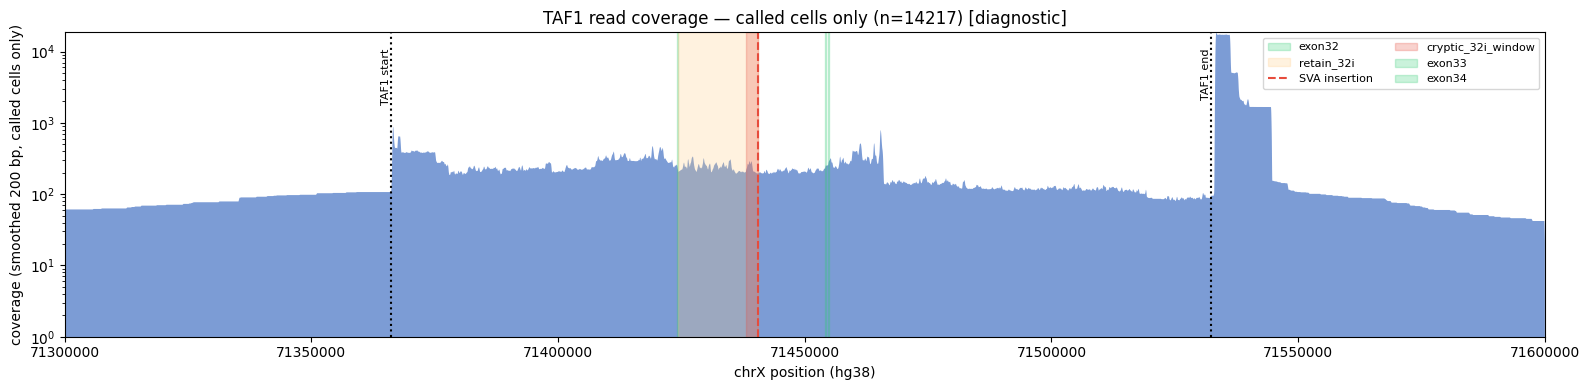

In [16]:
import numpy as np

# NOTE: diagnostic / exploratory only. Full-read coverage has the same span-vs-CIGAR
# caveat as the old window counts (a spliced-through read still contributes coverage
# across the whole intron) -- useful for *visually* checking for a coverage feature near
# the SVA site, not as a per-cell quantitative metric (use df_class / retention_ratio above).

CHROM = "chrX"
START = 71300000
END   = 71600000
TAF1_START = 71366131
TAF1_END   = 71532374

# --- coverage (called cells only) ---
cov = np.zeros(END - START, dtype=np.int32)

with pysam.AlignmentFile(str(BAM), "rb") as bam:
    for read in bam.fetch(CHROM, START, END):
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if not read.is_reverse:
            continue
        if read.has_tag("NH") and read.get_tag("NH") > 1:
            continue
        if not read.has_tag("CB") or read.get_tag("CB") not in CALLED_CELLS:
            continue
        rs = max(read.reference_start, START) - START
        re = min(read.reference_end,   END)   - START
        if re > rs:
            cov[rs:re] += 1

WIN = 200
cov_smooth = np.convolve(cov, np.ones(WIN) / WIN, mode="same")
x = np.arange(START, END)

# --- plot ---
fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(x, cov_smooth, color="#4472C4", alpha=0.7, linewidth=0)

ANNOTS = {
    "exon32":             (71424154, 71424238, "#2ecc71"),
    "retain_32i":         (71424239, 71440488, "#ffcc80"),
    "SVA insertion":      (71440488, 71440488, "#e74c3c"),
    "cryptic_32i_window": (71438000, 71440488, "#e74c3c"),
    "exon33":             (71454170, 71454237, "#2ecc71"),
    "exon34":             (71454741, 71454857, "#2ecc71"),
}
for label, (s, e, color) in ANNOTS.items():
    if s == e:
        ax.axvline(s, color=color, lw=1.5, ls="--", label=label)
    else:
        ax.axvspan(s, e, alpha=0.25, color=color, label=label)

for pos, label in [(TAF1_START, "TAF1 start"), (TAF1_END, "TAF1 end")]:
    ax.axvline(pos, color="black", lw=1.5, ls=":")
    ax.text(pos, cov_smooth.max() * 0.6, label, rotation=90,
            va="top", ha="right", fontsize=8)

ax.set_xlim(START, END)
ax.set_ylim(1, cov_smooth.max())
ax.set_xlabel("chrX position (hg38)")
ax.set_ylabel(f"coverage (smoothed {WIN} bp, called cells only)")
ax.set_title(f"TAF1 read coverage — called cells only (n={len(CALLED_CELLS)}) [diagnostic]")
ax.ticklabel_format(axis="x", style="plain")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.yscale("log")
plt.tight_layout()
plt.show()

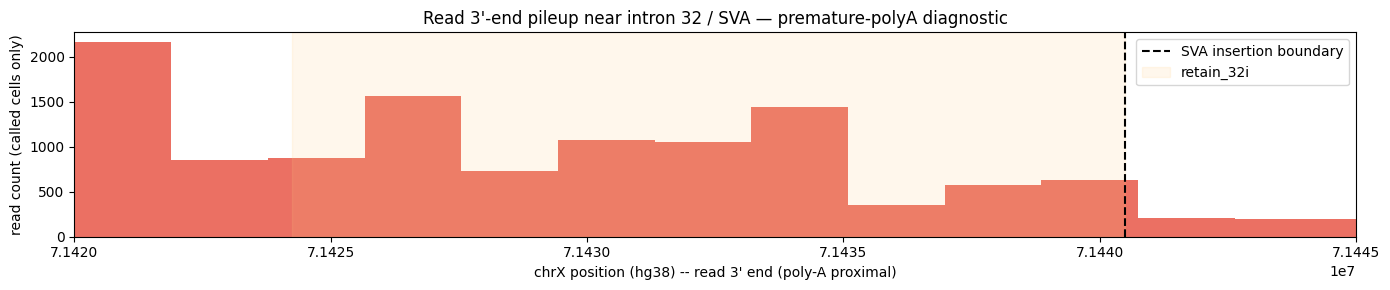

In [17]:
# 3'-end pileup check: for a '+' strand gene with 10x 3' chemistry, reverse-strand reads'
# reference_end approximates the poly-A-proximal (true transcript 3') end. A genuine
# premature-polyadenylation event inside the SVA/intron (the other XDP TAF1 mechanism,
# distinct from simple intron retention) would show a sharp local pileup of read 3'-ends
# near the insertion site; diffuse background (e.g. internal priming on nascent pre-mRNA)
# would not. This is exploratory -- regtools/Step B can't see non-spliced premature
# termination, so this stays a separate diagnostic, not a per-cell quantitative feature.
window_start, window_end = 71420000, 71445000
three_prime_ends = []
with pysam.AlignmentFile(str(BAM), "rb") as bam:
    for read in bam.fetch(CHROM, window_start, window_end):
        if read.is_unmapped or read.is_secondary or read.is_supplementary or not read.is_reverse:
            continue
        if read.has_tag("NH") and read.get_tag("NH") > 1:
            continue
        if not read.has_tag("CB") or read.get_tag("CB") not in CALLED_CELLS:
            continue
        three_prime_ends.append(read.reference_end)

fig, ax = plt.subplots(figsize=(14, 3))
ax.hist(three_prime_ends, bins=200, color="#e74c3c", alpha=0.8)
ax.axvline(SVA_POS, color="black", lw=1.5, ls="--", label="SVA insertion boundary")
ax.axvspan(71424239, 71440488, alpha=0.15, color="#ffcc80", label="retain_32i")
ax.set_xlim(window_start, window_end)
ax.set_xlabel("chrX position (hg38) -- read 3' end (poly-A proximal)")
ax.set_ylabel("read count (called cells only)")
ax.set_title("Read 3'-end pileup near intron 32 / SVA — premature-polyA diagnostic")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
print("Cells with any TAF1 reads:", (df["taf1_gene"] > 0).sum())
print(f"Boundary-region reads dropped for missing CB/UB tag: "
      f"{qc['dropped_no_barcode_or_umi']} / {qc['total_overlapping']} "
      f"({qc['dropped_no_barcode_or_umi_frac']:.1%})")
print("Mean UMIs per cell (non-zero cells):")
for col in df.columns:
    if col == "retention_ratio":
        continue
    nonzero = df[col][df[col] > 0]
    print(f"  {col:25s}: {len(nonzero):5d} cells, mean={nonzero.mean():.2f}")
print(f"\nretention_ratio = retained / (retained + spliced_canonical): "
      f"{df['retention_ratio'].notna().sum()} cells with a defined ratio, "
      f"mean={df['retention_ratio'].mean():.3f}")

Cells with any TAF1 reads: 11586
Boundary-region reads dropped for missing CB/UB tag: 1195 / 15147 (7.9%)
Mean UMIs per cell (non-zero cells):
  taf1_gene                : 11586 cells, mean=2.32
  exon32                   :   254 cells, mean=1.00
  exon33                   :   227 cells, mean=1.02
  exon34                   :   289 cells, mean=1.02
  spliced_canonical        :    29 cells, mean=1.00
  spliced_cryptic          :    34 cells, mean=1.00
  retained                 :    24 cells, mean=1.00
  other                    :  4271 cells, mean=1.37

retention_ratio = retained / (retained + spliced_canonical): 53 cells with a defined ratio, mean=0.453


In [ ]:
# out_path = BAM.parent / "taf1_region_counts.csv"
# df.to_csv(out_path)
# print(f"Saved to {out_path}")

In [ ]:
ff

In [ ]:
adata_s.obs = adata_s.obs.merge(df, left_on="original_barcode", right_index=True, how="left")
adata_s.obs.index = obs_indexss
adata_s.obs

In [ ]:
sc.pl.embedding(adata_s[adata_s.obs["Neighborhood_name"] == "Subpallium GABA"], basis="spatial", color=["taf1_gene", "exon32", "retained", "spliced_canonical", "retention_ratio"], ncols=1, cmap="viridis", size=20)

In [ ]:
%%bash

count_umis () {   # usage: count_umis BAM "chrX:start-end"sss
  samtools view -e '[xf]==25' "$1" "$2" \
  | awk '{
      cb=""; ub="";
      for(i=12;i<=NF;i++){
        if($i ~ /^CB:Z:/) cb=substr($i,6);
        if($i ~ /^UB:Z:/) ub=substr($i,6);
      }
      if(cb!="" && ub!="") print cb"\t"ub
    }' \
  | sort -u | wc -l
}

# numerator: 32i cryptic polyA peak (tight window around the cleavage site)
count_umis /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam chrX:71439000-71440488

# denominator: canonical 3'UTR peak (terminal exon — see strand caveat below)
count_umis /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam chrX:71530000-71532374

272
117
